<a href="https://colab.research.google.com/github/BE7nHgA6/Eco-Type-Forest-Cover-Type-Prediction-Using-Machine-Learning/blob/main/Eco_type_Forest_cover_type_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#Data colllection
import pandas as pd
df = pd.read_csv("/content/cover_type (1) .csv")
df.head()


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [ ]:
#check shape
df.shape

(145890, 13)

In [ ]:
#check columns
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
#basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
#statistical summary
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [ ]:
#check target column
df['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [ ]:
#Data understanding
#check missing values
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#check unique values
df['Cover_Type'].unique()

array(['Aspen', 'Lodgepole Pine', 'Spruce/Fir', 'Krummholz',
       'Ponderosa Pine', 'Douglas-fir', 'Cottonwood/Willow'], dtype=object)

In [ ]:
#wilderness area
df['Wilderness_Area'].value_counts()

,count
Wilderness_Area,
1,134367
3,6349
4,4675
2,499


In [ ]:
#soil type
df['Soil_Type'].value_counts()

,count
Soil_Type,
29,60696
12,29144
30,18158
23,10150
20,6098
16,2219
24,2169
10,2142
18,1829


In [ ]:
# Data cleaning and transformation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR))).sum()

print(outliers)

Elevation                              4448
Aspect                                    0
Slope                                  3385
Horizontal_Distance_To_Hydrology       2473
Vertical_Distance_To_Hydrology         7123
Horizontal_Distance_To_Roadways           0
Hillshade_9am                          5242
Hillshade_Noon                         3211
Hillshade_3pm                          3087
Horizontal_Distance_To_Fire_Points        0
Wilderness_Area                       11523
Soil_Type                                 0
dtype: int64


In [ ]:
# Only numerical columns
num_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points']


In [ ]:
#check for skewness
df[num_cols].skew()

,0
Elevation,-0.664497
Aspect,0.689432
Slope,0.943937
Horizontal_Distance_To_Hydrology,0.984953
Vertical_Distance_To_Hydrology,1.792939
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_9am,-1.286839
Hillshade_Noon,-0.945446
Hillshade_3pm,-0.165213
Horizontal_Distance_To_Fire_Points,0.365249


In [ ]:
#handle skewness-make values positive
df['Vertical_Distance_To_Hydrology'] = df['Vertical_Distance_To_Hydrology'] + abs(df['Vertical_Distance_To_Hydrology'].min()) + 1

In [ ]:
#apply log transformation
import numpy as np

df['Vertical_Distance_To_Hydrology'] = np.log1p(df['Vertical_Distance_To_Hydrology'])

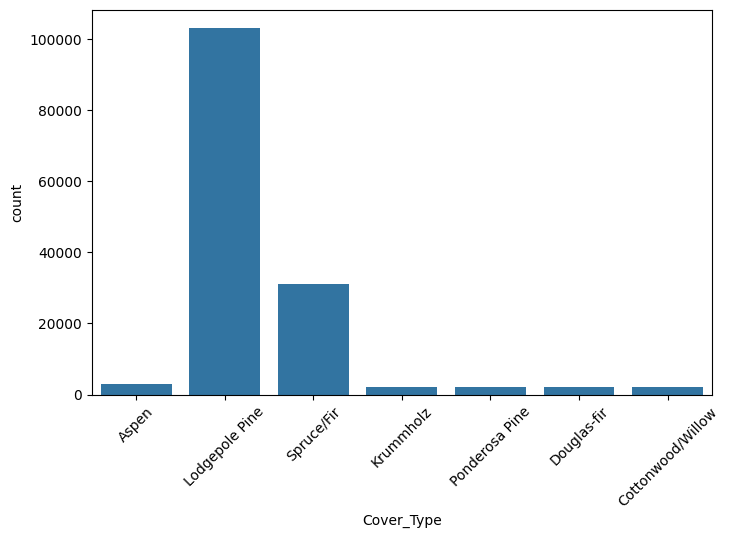

In [ ]:
#EDA
#1. Target Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Cover_Type', data=df)
plt.xticks(rotation=45)
plt.show()

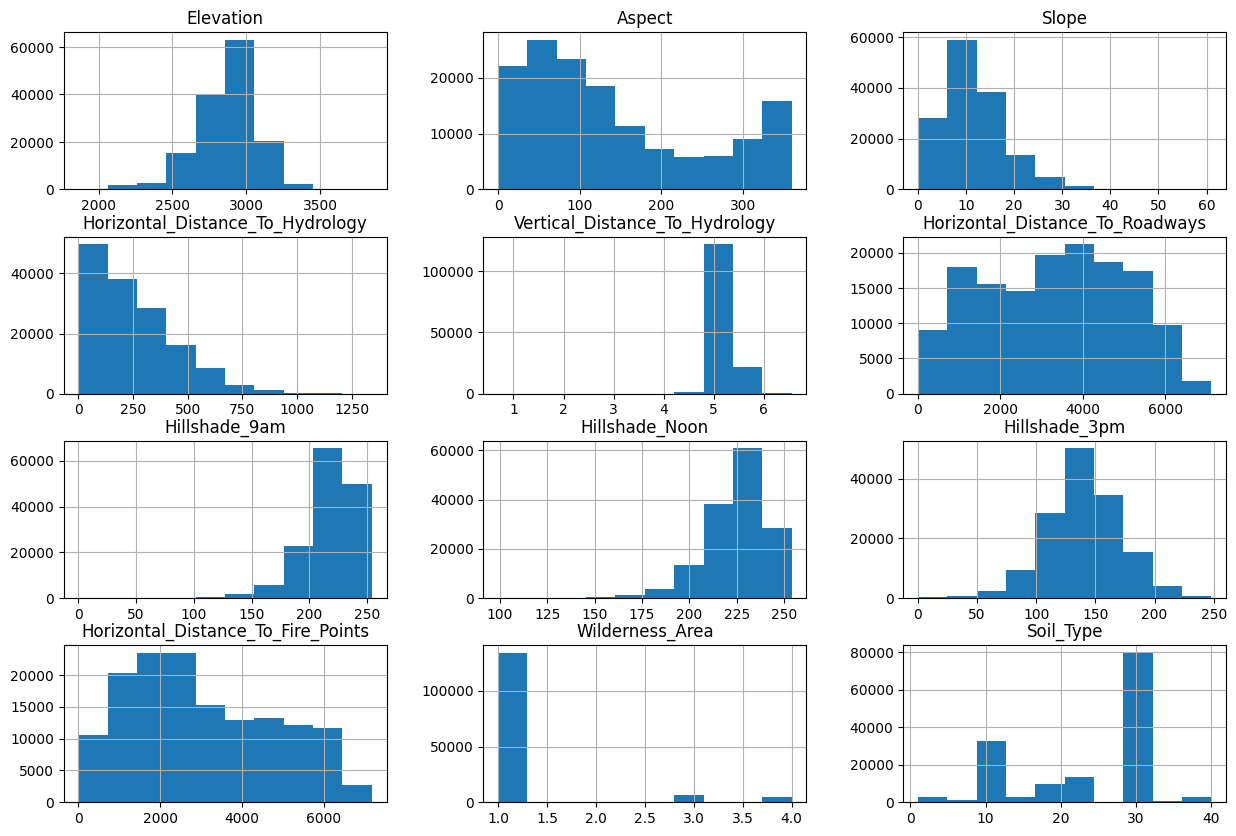

In [ ]:
#2.Histogram
df.hist(figsize=(15,10))
plt.show()

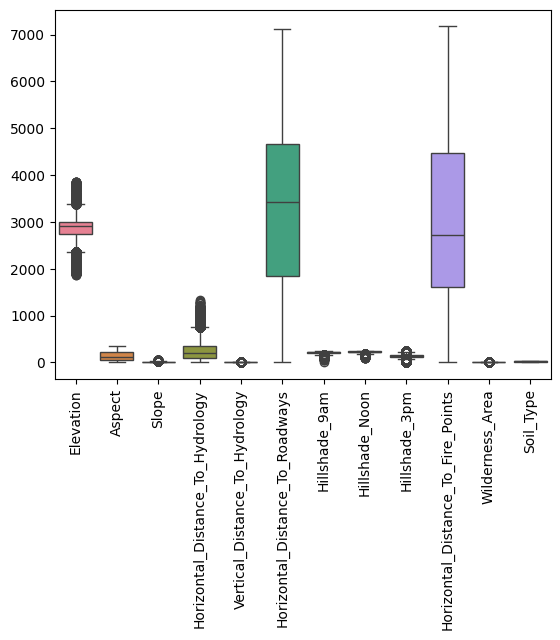

In [ ]:
#3.Boxplot
sns.boxplot(data=df.drop('Cover_Type', axis=1))
plt.xticks(rotation=90)
plt.show()

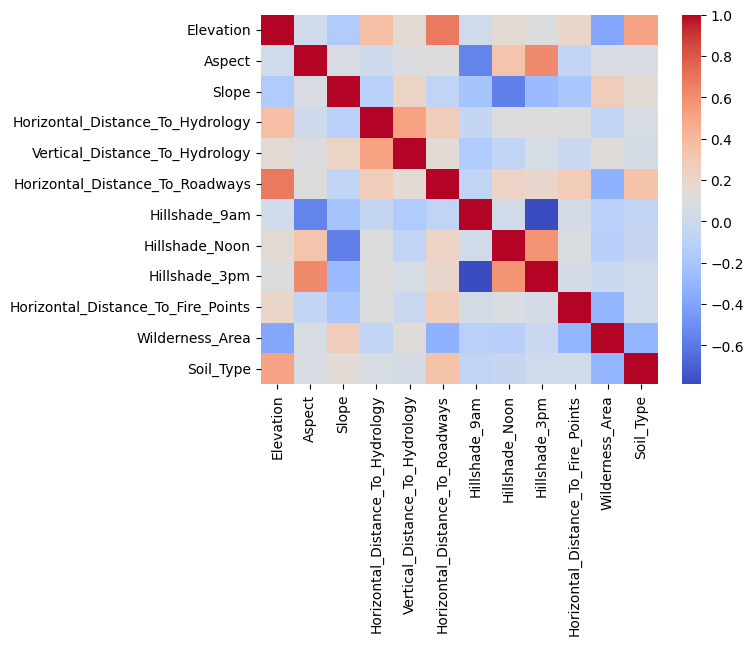

In [ ]:
#4.Heatmap
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

In [13]:
#Encoding
#encoder type

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Cover_Type'] = le.fit_transform(df['Cover_Type'])

In [14]:
#save the encoder
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [15]:
#handle categorical features
df = pd.get_dummies(df, columns=['Wilderness_Area', 'Soil_Type'], drop_first=True)

In [16]:
#Train-Test Split
#Separate Features & Target
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

In [17]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
#handle class imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [19]:
#check new distribution
y_train_sm.value_counts()

,count
Cover_Type,
4,82457
5,82457
1,82457
6,82457
3,82457
0,82457
2,82457


In [ ]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.514874220302968


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#model building

#apply feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [ ]:
#1.Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.6993968058125986


In [ ]:

#2.decision tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)

y_pred_dt = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 0.9387552265405442


In [ ]:
#comparison of train and test accuracy
print("Train Accuracy:", dt.score(X_train_sm, y_train_sm))
print("Test Accuracy:", dt.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9387552265405442


In [ ]:
#3.Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Random Forest: 0.9553430666940845


In [ ]:
#check Accuracy
print("Train Accuracy:", rf.score(X_train_sm, y_train_sm))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9553430666940845


In [ ]:
#4.XG boost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import accuracy_score
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:25:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: 0.9150730002056344


In [ ]:
xgb = XGBClassifier(eval_metric='mlogloss')

In [ ]:
#5.KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sm, y_train_sm)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9062992665707039


In [20]:
import joblib

rf = joblib.load("/content/label_encoder.pkl")

In [22]:
#Hyperparameter tuning
#RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train_sm, y_train_sm)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 150]},
                   random_state=42, verbose=2)

In [23]:
#best parameters
print("Best Params:", random_search.best_params_)

Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [24]:
#Evaluate tuned model
best_rf = random_search.best_estimator_

In [25]:
#prediction
y_pred = best_rf.predict(X_test)

In [26]:
#check for accuracy score
from sklearn.metrics import accuracy_score

y_pred = best_rf.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.9542806223867297


In [27]:
import joblib
joblib.dump(best_rf, "final_model.pkl")

['final_model.pkl']

In [28]:
import joblib
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [33]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-05-09 10:36:40--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-05-09 10:36:40--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-09T11%3A26%3A21Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-09T1

In [34]:
!pip install streamlit-option-menu

In [38]:
!streamlit run /content/app.py &>/content/logs.txt &

In [39]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://brakes-interventions-legislative-expertise.trycloudflare.com


In [43]:
#streamlit
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load model and encoder
model = joblib.load("final_model.pkl")
le = joblib.load("label_encoder.pkl")
st.set_page_config(page_title="EcoType: Forest Cover Type Prediction", layout="wide")

st.title("🌿 EcoType: Forest Cover Type Prediction")
st.markdown("""
    <style>

    .stApp {
        background-color: #FFD580

    }
    h1, h2, h3 {
        font-family: 'Arial';
        color: #2c3e50;
    }
    </style>

""", unsafe_allow_html=True)

st.write("Enter the details below to predict forest cover type")

# --- INPUT FIELDS ---
Elevation = st.number_input("Elevation", min_value=0)
Aspect = st.number_input("Aspect", min_value=0, max_value=360)
Slope = st.number_input("Slope", min_value=0)

Horizontal_Distance_To_Hydrology = st.number_input("Horizontal Distance To Hydrology")
Vertical_Distance_To_Hydrology = st.number_input("Vertical Distance To Hydrology")
Horizontal_Distance_To_Roadways = st.number_input("Horizontal Distance To Roadways")

Hillshade_9am = st.number_input("Hillshade 9am", min_value=0, max_value=255)
Hillshade_Noon = st.number_input("Hillshade Noon", min_value=0, max_value=255)
Hillshade_3pm = st.number_input("Hillshade 3pm", min_value=0, max_value=255)

Horizontal_Distance_To_Fire_Points = st.number_input("Distance To Fire Points")

Wilderness_Area = st.selectbox("Wilderness Area", [1, 2, 3, 4])
Soil_Type = st.selectbox("Soil Type", list(range(1, 41)))

# --- CREATE DATAFRAME ---
input_data = pd.DataFrame({
    'Elevation': [Elevation],
    'Aspect': [Aspect],
    'Slope': [Slope],
    'Horizontal_Distance_To_Hydrology': [Horizontal_Distance_To_Hydrology],
    'Vertical_Distance_To_Hydrology': [Vertical_Distance_To_Hydrology],
    'Horizontal_Distance_To_Roadways': [Horizontal_Distance_To_Roadways],
    'Hillshade_9am': [Hillshade_9am],
    'Hillshade_Noon': [Hillshade_Noon],
    'Hillshade_3pm': [Hillshade_3pm],
    'Horizontal_Distance_To_Fire_Points': [Horizontal_Distance_To_Fire_Points],
    'Wilderness_Area': [Wilderness_Area],
    'Soil_Type': [Soil_Type]
})

# --- APPLY SAME ENCODING ---
input_data = pd.get_dummies(input_data, columns=['Wilderness_Area', 'Soil_Type'])

# Match training columns
model_columns = joblib.load("model_columns.pkl")

for col in model_columns:
    if col not in input_data.columns:
        input_data[col] = 0

input_data = input_data[model_columns]

# --- PREDICTION ---
if st.button("Predict"):
    prediction = model.predict(input_data)
    result = le.inverse_transform(prediction)

    st.success(f"🌲 Predicted Forest Cover Type: {result[0]}")

Overwriting app.py
